# Code Analysis and Classification with Deep Learning
*Prepared by: Adham Ahmed Desouky*
*Institution: Nile University*  
*Course: CSCI417/ECEN425: Machine Intelligence*  
*Presented to: Dr. Ghada Khoriba*

## **1. Importing Required Libraries**

In [1]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import itertools

## **2. Loading and Preprocessing the Dataset**



================== Dataset Information ==================
Data after removing duplicates: 16342 samples

================== Language Distribution ==================
📌 java: 4546 samples
📌 c: 4261 samples
📌 cpp: 4237 samples
📌 python: 3298 samples

================== New Language Distribution ==================
📌 c: 4546 samples
📌 cpp: 4546 samples
📌 python: 4546 samples
📌 java: 4546 samples



<ipython-input-2-baa54e7398af>:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=new_class_distribution.index, y=new_class_distribution.values, palette="viridis")


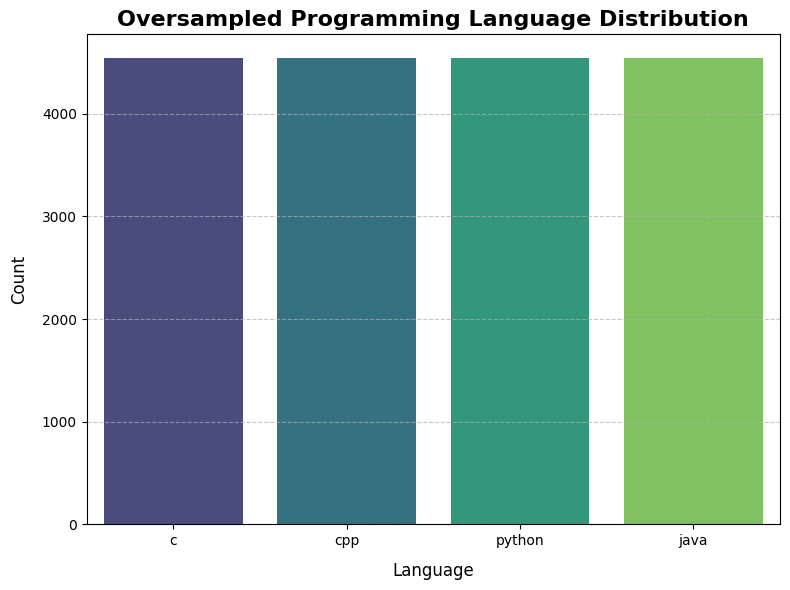

In [2]:
from sklearn.utils import resample

# Load the dataset
data = pd.read_csv("code_snippets_yarab_final.csv")

# Remove duplicates
data = data.drop_duplicates(subset='Code', keep='first')
print("\n================== Dataset Information ==================")
print(f"Data after removing duplicates: {data.shape[0]} samples\n")

# Check class distribution
class_distribution = data['Language'].value_counts()

# Print class distribution in a visually structured format
print("================== Language Distribution ==================")
for language, count in class_distribution.items():
    print(f"📌 {language}: {count} samples")
print("==========================================================\n")

# Oversample the minority classes
max_samples = class_distribution.max()
oversampled_data = pd.DataFrame()

for language in class_distribution.index:
    language_data = data[data['Language'] == language]
    oversampled_language_data = resample(language_data, replace=True, n_samples=max_samples, random_state=42)
    oversampled_data = pd.concat([oversampled_data, oversampled_language_data])

# Shuffle the oversampled dataset
oversampled_data = oversampled_data.sample(frac=1, random_state=42).reset_index(drop=True)

# Check new class distribution
new_class_distribution = oversampled_data['Language'].value_counts()

# Print new class distribution
print("================== New Language Distribution ==================")
for language, count in new_class_distribution.items():
    print(f"📌 {language}: {count} samples")
print("==============================================================\n")

# Plot the new class distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=new_class_distribution.index, y=new_class_distribution.values, palette="viridis")
plt.title("Oversampled Programming Language Distribution", fontsize=16, weight='bold')
plt.xlabel("Language", fontsize=12, labelpad=10)
plt.ylabel("Count", fontsize=12, labelpad=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save and show the graph
plt.savefig("oversampled_language_distribution.png", dpi=300)
plt.show()


## **3. Tokenization and Encoding**

In [3]:
code_snippets = data['Code']
languages = data['Language']
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(languages)
labels = to_categorical(encoded_labels)

In [4]:
import re

def custom_tokenizer(code):
    token_pattern = r"""
    \b\w+\b                  # Words: identifiers, keywords
    | [\(\)\{\}\[\]]         # Parentheses, braces, brackets
    | [\+\-\*/%]             # Arithmetic operators
    | ==|!=|<=|>=|&&|\|\||-> # Comparison and logical operators
    | [=;:,]                 # Assignment and punctuation
    | ["'][^"']*["']         # String literals
    | \d+\.\d+|\d+           # Numbers (integers and floats)
    """
    regex = re.compile(token_pattern, re.VERBOSE)
    return regex.findall(code)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(code_snippets, labels, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((13073,), (3269,), (13073, 4), (3269, 4))

In [6]:
# Tokenize the code snippets
X_train_tokens = [custom_tokenizer(snippet) for snippet in X_train]
X_test_tokens = [custom_tokenizer(snippet) for snippet in X_test]


In [7]:
from collections import Counter

all_tokens = [token for snippet in X_train_tokens for token in snippet]
token_counts = Counter(all_tokens)

max_words = 10000
vocab = {token: i+1 for i, (token, _) in enumerate(token_counts.most_common(max_words))}
vocab["<UNK>"] = 0  # Token for unknown words


In [8]:
def tokens_to_sequences(tokens, vocab):
    return [vocab.get(token, vocab["<UNK>"]) for token in tokens]

# Convert training and test tokens to sequences
X_train_seq = [tokens_to_sequences(tokens, vocab) for tokens in X_train_tokens]
X_test_seq = [tokens_to_sequences(tokens, vocab) for tokens in X_test_tokens]


In [9]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_sequence_length = 500
X_train_padded = pad_sequences(X_train_seq, maxlen=max_sequence_length, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=max_sequence_length, padding='post', truncating='post')

## **4. Model Architecture**

In [10]:
# Model parameters
vocab_size = 5000         # Size of the tokenizer vocabulary
embedding_dim = 128       # Dimension of the embedding vectors
max_length = 500          # Length of the padded sequences
gru_units = 128           # Number of GRU units
dropout_rate = 0.3        # Dropout rate
num_classes = 4           # Number of languages to classify


In [11]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define Input Layer
input_layer = Input(
    shape=(max_length,),
    dtype='int32',
    name='Input_Layer'
)

# Embedding Layer
embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    input_length=max_length,
    name='Embedding_Layer'
)(input_layer)

# Bidirectional GRU Layer
gru_layer = Bidirectional(
    GRU(units=gru_units, return_sequences=False),
    name='Bidirectional_GRU_Layer'
)(embedding_layer)

# Dropout Layer 1
dropout_layer_1 = Dropout(
    rate=dropout_rate,
    name='Dropout_Layer_1'
)(gru_layer)

# Dense Layer
dense_layer = Dense(
    units=64,
    activation='relu',
    name='Dense_Layer'
)(dropout_layer_1)

# Dropout Layer 2
dropout_layer_2 = Dropout(
    rate=dropout_rate,
    name='Dropout_Layer_2'
)(dense_layer)

# Output Layer
output_layer = Dense(
    units=num_classes,
    activation='softmax',
    name='Output_Layer'
)(dropout_layer_2)

# Create Model
model = Model(
    inputs=input_layer,
    outputs=output_layer,
    name='Code_Classification_Model'
)

# Compile Model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display Model Summary
model.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Code_Classification_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Input_Layer (InputLayer)             │ (None, 500)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Embedding_Layer (Embedding)          │ (None, 500, 128)            │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Bidirectional_GRU_Layer              │ (None, 256)                 │         198,144 │
│ (Bidirectional)                      │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dropout_Layer_1 (Dropout)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense_Layer (Dense)                  │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dropout_Layer_2 (Dropout)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output_Layer (Dense)                 │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 854,852 (3.26 MB)

 Trainable params: 854,852 (3.26 MB)

 Non-trainable params: 0 (0.00 B)

## **5. Training the Model**

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

# Configure Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',          # Monitor validation loss
    patience=3,                  # Stop training after 3 epochs of no improvement
    restore_best_weights=True,   # Restore the model weights from the best epoch
    verbose=1                    # Enable verbose mode to show early stopping messages
)

# Train the Model
history = model.fit(
    X_train_padded,
    y_train,
    epochs=10,                   # Maximum number of epochs
    batch_size=32,               # Training batch size
    validation_data=(X_test_padded, y_test),  # Validation data
    callbacks=[early_stopping]   # Include early stopping in callbacks
)

Epoch 1/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - accuracy: 0.6277 - loss: 0.8264 - val_accuracy: 0.8559 - val_loss: 0.4260
Epoch 2/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.8975 - loss: 0.2985 - val_accuracy: 0.9403 - val_loss: 0.1783
Epoch 3/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.9550 - loss: 0.1445 - val_accuracy: 0.9486 - val_loss: 0.1625
Epoch 4/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.9669 - loss: 0.1090 - val_accuracy: 0.9486 - val_loss: 0.1784
Epoch 5/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.9710 - loss: 0.1015 - val_accuracy: 0.9532 - val_loss: 0.1469
Epoch 6/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.9776 - loss: 0.0743 - val_accuracy: 0.9507 - val_loss: 0.1772
Epoch 7/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.9817 - loss: 0.0586 - val_accuracy: 0.9468 - val_loss: 0.1832
Epoch 8/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.9844 - loss: 0.0550 - 

## **6. Evaluating the Model**

Test Accuracy: 95.32%
Test Loss: 0.1469
Overall Accuracy (Sklearn): 95.32%


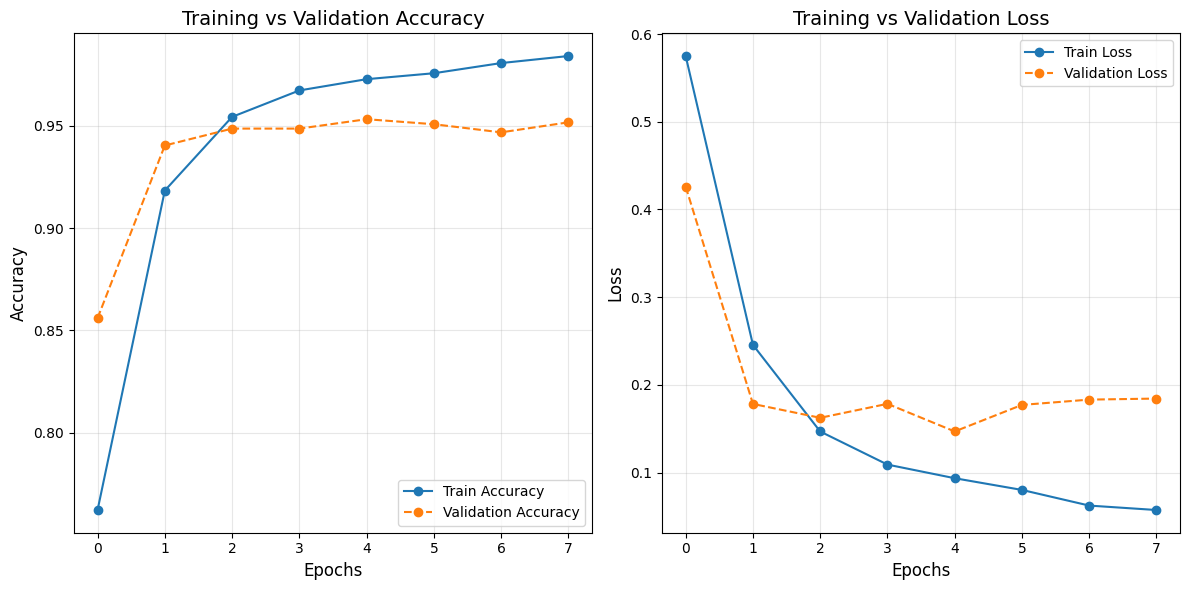

In [13]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Evaluate the model on the test set
loss, test_accuracy = model.evaluate(X_test_padded, y_test, verbose=0)  # Suppress detailed output
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {loss:.4f}")

# Generate predictions
y_pred = model.predict(X_test_padded, verbose=0)
y_pred_classes = y_pred.argmax(axis=1)  # Convert probabilities to class indices
y_test_classes = y_test.argmax(axis=1)   # True class indices

# Calculate accuracy using sklearn
overall_accuracy = accuracy_score(y_test_classes, y_pred_classes)
print(f"Overall Accuracy (Sklearn): {overall_accuracy * 100:.2f}%")

# Visualization: Training vs Validation Accuracy
plt.figure(figsize=(12, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o', linestyle='-')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o', linestyle='--')
plt.title('Training vs Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o', linestyle='-')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o', linestyle='--')
plt.title('Training vs Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)

# Display Plots
plt.tight_layout()
plt.show()


103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Model Performance Metrics:
Accuracy: 0.95
Precision (Weighted): 0.95
Recall (Weighted): 0.95
F1-Score (Weighted): 0.95

Detailed Classification Report:
              precision    recall  f1-score   support

           c       0.93      0.94      0.93       843
         cpp       0.93      0.94      0.93       881
        java       0.99      0.96      0.97       885
      python       0.98      0.98      0.98       660

    accuracy                           0.95      3269
   macro avg       0.95      0.96      0.95      3269
weighted avg       0.95      0.95      0.95      3269



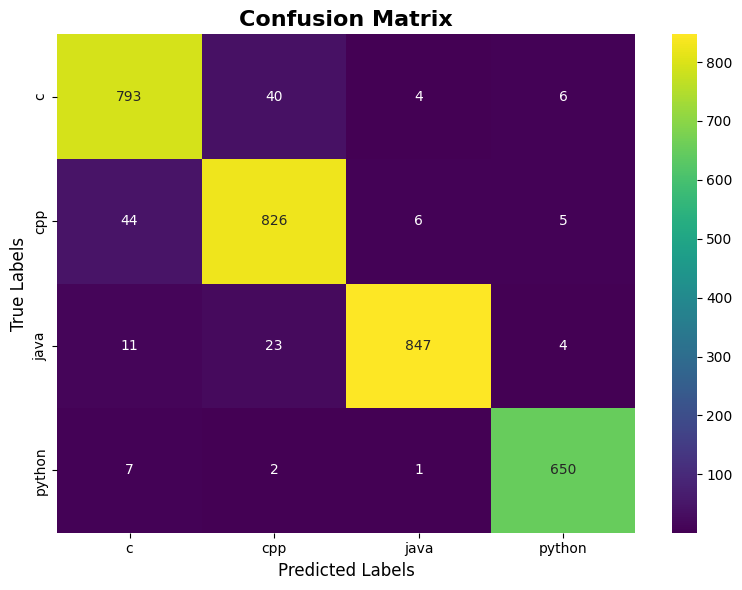

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Evaluate model predictions (replace this with your actual predictions)
predictions = model.predict(X_test_padded)  # Assuming your model is called 'model'
predicted_classes = np.argmax(predictions, axis=1)

# Convert y_test from one-hot encoded format to integer format
y_test_classes = np.argmax(y_test, axis=1)

# Calculate metrics
accuracy = accuracy_score(y_test_classes, predicted_classes)
precision = precision_score(y_test_classes, predicted_classes, average='weighted')
recall = recall_score(y_test_classes, predicted_classes, average='weighted')
f1 = f1_score(y_test_classes, predicted_classes, average='weighted')

# Print performance metrics
print("Model Performance Metrics:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision (Weighted): {precision:.2f}")
print(f"Recall (Weighted): {recall:.2f}")
print(f"F1-Score (Weighted): {f1:.2f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test_classes, predicted_classes, target_names=list(label_encoder.classes_)))

# Confusion matrix
conf_matrix = confusion_matrix(y_test_classes, predicted_classes)
labels = list(label_encoder.classes_)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='viridis', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix', fontsize=16, weight='bold')
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()



## **7. Code Snippet Example**

In [15]:
#Example code snippet
new_code_snippet = ["""
    // Hybrid-like code to confuse the classifier
#include <stdio.h>
#define PI 3.14

template <typename T>
class MyTemplate {
public:
    T data;
    MyTemplate(T val) : data(val) {}
    void display() { std::cout << "Value: " << data << std::endl; }
};

int main() {
    // Python-like list comprehension disguised in a C-style loop
    int arr[] = {1, 2, 3, 4, 5};
    int result[5];
    for (int i = 0; i < 5; i++) {
        result[i] = arr[i] * arr[i];  // Squaring elements
    }

    // Mixing printf and cout
    printf("Hello, World!\n");
    MyTemplate<double> obj(PI);
    obj.display();

    // Function pointer weirdness
    void (*fun_ptr)(int) = [](int x) { std::cout << "Lambda: " << x << std::endl; };
    fun_ptr(10);

    // Embedded Python-like dictionary
    struct Dict {
        const char* key;
        int value;
    };
    Dict my_dict[] = {{"a", 1}, {"b", 2}, {"c", 3}};
    for (const auto& item : my_dict) {
        std::cout << item.key << ": " << item.value << std::endl;
    }

    return 0;
}

"""]

#Tokenize and pad the snippet
new_snippet_tokens = [custom_tokenizer(snippet) for snippet in new_code_snippet]
new_snippet_seq = [tokens_to_sequences(tokens, vocab) for tokens in new_snippet_tokens]
new_snippet_padded = pad_sequences(new_snippet_seq, maxlen=max_sequence_length, padding='post', truncating='post')
print(new_snippet_padded)

#Predict the probabilities for each language
predictions = model.predict(new_snippet_padded)

#Extract probabilities for the first input (since predict returns an array for batch inputs)
predicted_probabilities = predictions[0]

#Map probabilities to language labels
language_confidences = {
    label_encoder.inverse_transform([i])[0]: f"{prob * 100:.2f}%"
    for i, prob in enumerate(predicted_probabilities)
}

#Print the confidence scores
for language, confidence in language_confidences.items():
    print(f"{language}: {confidence}")

[[  33   33    0    9 2133  285  103    0   77    0   32  224   47   59
  1247   53  508  205  259  146   54    0    7   23    6  146   75    3
     0    1  146  160    2    6   75    1  160    2    7    8   22  678
     1    2    7   30    6    6   99    0   75   30    6    6  181    3
     8    8    3   16   97    1    2    7   33   33 6600    9 2133  133
     0    0   44   38  424    9 1244  927   16  235   10   11    5    7
    19    4   29    4   53    4   64    4   73    8    3   16   76   10
    73   11    3   24    1   16   17    5   13    3   17   73    3   17
    14   14    2    7   76   10   17   11    5  235   10   17   11   12
   235   10   17   11    3   33   33    0 1482    8   33   33    0   74
   129   99   74    1    0    2    3    0   45  221    1 1247    2    3
   221  678    1    2    3   33   33  832 1469    0   22    1   12    0
     2    1   16    2    5   10   11    1   16   31    2    7   30    6
     6   99    0   31   30    6    6  181    3    8    3    0   

In [16]:
# Save the model
model.save("Language_Classification_biGRU.h5")
print("Model saved to disk.")


Model saved to disk.
